# combined_cost_service_pareto_frontier_plot

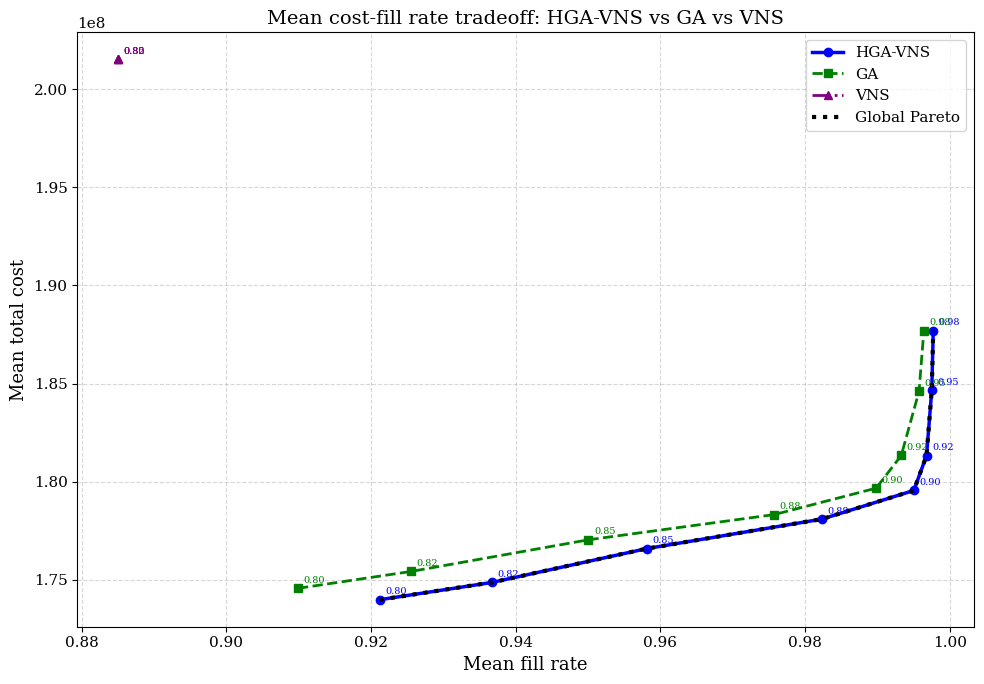

In [4]:
#Load ALL results together
import pandas as pd
import matplotlib.pyplot as plt

# Load all results
df_hga = pd.read_csv("output_hga_vns/TRADEOFF_SERVICE_TARGET_RESULTS_HGA-VNS_6.csv")
df_ga  = pd.read_csv("output_ga_ipox_2/TRADEOFF_SERVICE_TARGET_RESULTS_GA_4.csv")
df_vns = pd.read_csv("output_vns/TRADEOFF_SERVICE_TARGET_RESULTS_VNS_4.csv")


# ✅ Rename for consistency
for df in [df_hga, df_ga, df_vns]:
    df.rename(columns={
        'mean_cost': 'total_cost',
        'mean_fill': 'fill_rate'
    }, inplace=True)


# Add method label
df_hga['method'] = 'HGA-VNS'
df_ga['method']  = 'GA'
df_vns['method'] = 'VNS'

# Combine all
df_all = pd.concat([df_hga, df_ga, df_vns], ignore_index=True)


# =====================================
# ✅ METHOD-WISE PARETO FUNCTION
# =====================================
def pareto_front(df):
    data = df[['total_cost', 'fill_rate']].values
    mask = [True] * len(df)

    for i, (c1, s1) in enumerate(data):
        for j, (c2, s2) in enumerate(data):
            if i != j:
                if (c2 <= c1 and s2 >= s1) and (c2 < c1 or s2 > s1):
                    mask[i] = False
                    break

    return df[mask]


# =====================================
# ✅ COMPUTE PARETO PER METHOD
# =====================================
#pareto_hga = pareto_front(df_hga.rename(columns={'mean_cost': 'total_cost', 'mean_service': 'fill_rate'})).sort_values('fill_rate') --- IGNORE ---
pareto_hga = pareto_front(df_hga).sort_values('fill_rate')
pareto_ga  = pareto_front(df_ga).sort_values('fill_rate')
pareto_vns = pareto_front(df_vns).sort_values('fill_rate')


# =====================================
# ✅ PLOT COMBINED PARETO
# =====================================
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'HGA-VNS': 'blue',
    'GA': 'green',
    'VNS': 'purple'
}

# --- HGA-VNS ---
ax.plot(
    pareto_hga['fill_rate'],
    pareto_hga['total_cost'],
    marker='o',
    linewidth=2.5,
    color=colors['HGA-VNS'],
    label='HGA-VNS'
)

# --- GA ---
ax.plot(
    pareto_ga['fill_rate'],
    pareto_ga['total_cost'],
    marker='s',
    linestyle='--',
    linewidth=2,
    color=colors['GA'],
    label='GA'
)

# --- VNS ---
ax.plot(
    pareto_vns['fill_rate'],
    pareto_vns['total_cost'],
    marker='^',
    linestyle='-.',
    linewidth=2,
    color=colors['VNS'],
    label='VNS'
)


# =====================================
# ✅ OPTIONAL: GLOBAL PARETO (ACROSS ALL METHODS)
# =====================================
df_all_clean = pd.concat([df_hga, df_ga, df_vns], ignore_index=True)
pareto_global = pareto_front(df_all_clean).sort_values('fill_rate')

ax.plot(
    pareto_global['fill_rate'],
    pareto_global['total_cost'],
    color='black',
    linestyle=':',
    linewidth=3,
    label='Global Pareto'
)


# =====================================
# ✅ ANNOTATE SERVICE LEVEL TARGET (IF EXISTS)
# =====================================
if 'svc_target' in df_hga.columns:
    for df, color in [
        (pareto_hga, colors['HGA-VNS']),
        (pareto_ga, colors['GA']),
        (pareto_vns, colors['VNS'])
    ]:
        for _, row in df.iterrows():
            ax.annotate(
                f"{row['svc_target']:.2f}",
                (row['fill_rate'], row['total_cost']),
                fontsize=7,
                color=color,
                xytext=(4,4),
                textcoords='offset points'
            )


# =====================================
# ✅ STYLE
# =====================================
ax.set_xlabel('Mean fill rate')
ax.set_ylabel('Mean total cost')
ax.set_title('Mean cost-fill rate tradeoff: HGA-VNS vs GA vs VNS')

ax.grid(True, linestyle='--', alpha=0.5)

# remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.savefig("combined_pareto_3A_methods.png", dpi=150)
plt.show()


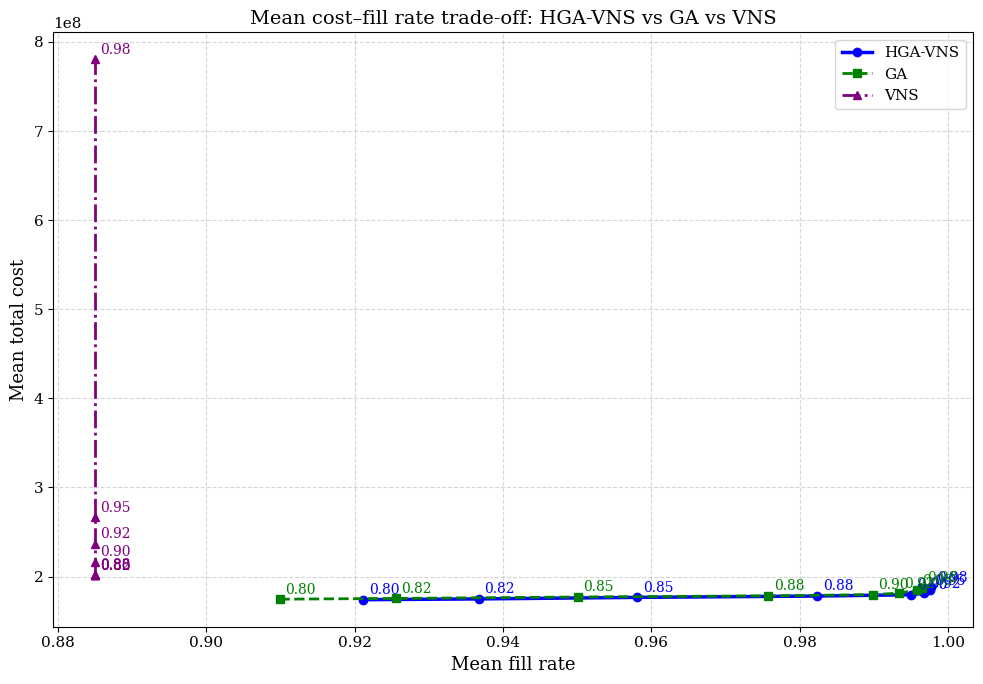

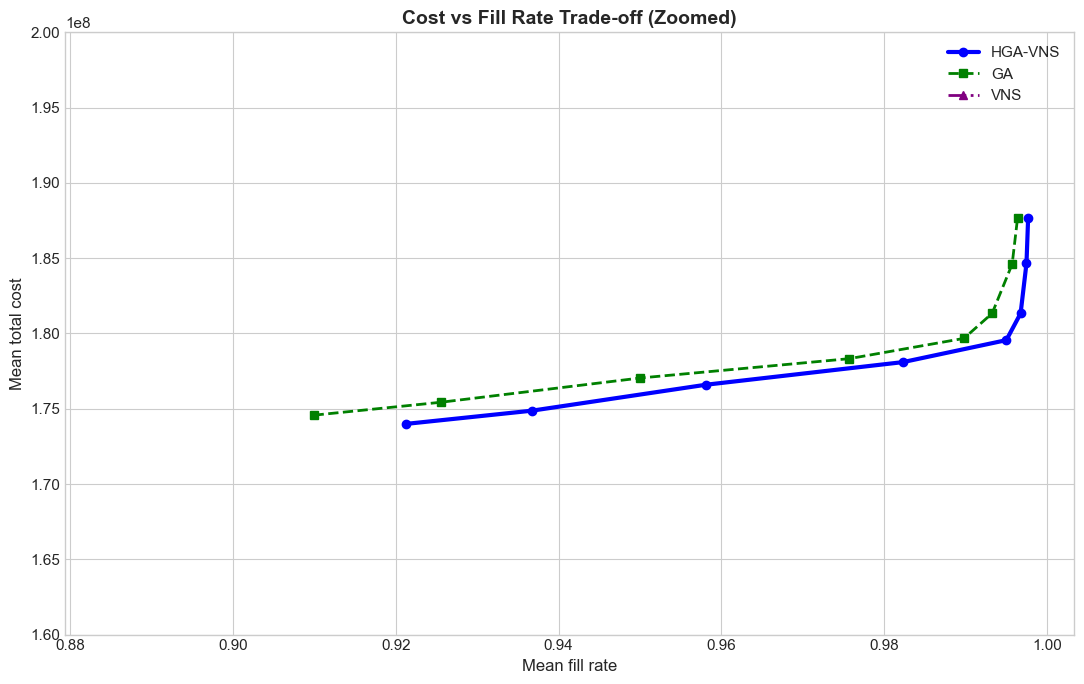

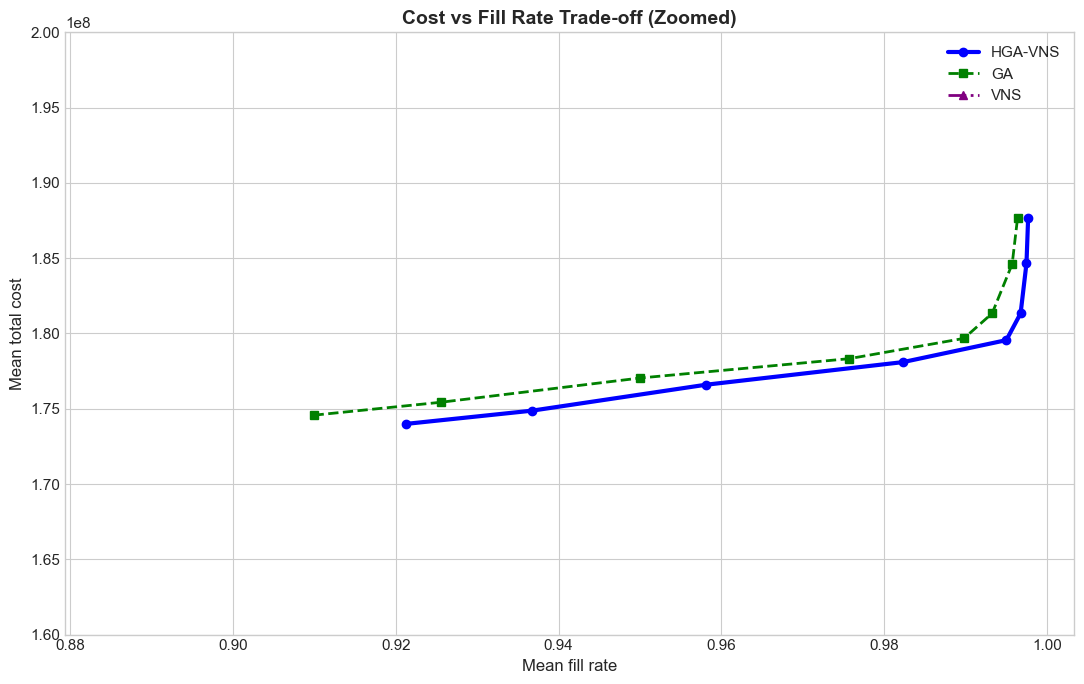

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================
# ✅ LOAD DATA
# =====================================
df_hga = pd.read_csv("output_hga_vns/TRADEOFF_SERVICE_TARGET_RESULTS_HGA-VNS_6.csv")
df_ga  = pd.read_csv("output_ga_ipox_2/TRADEOFF_SERVICE_TARGET_RESULTS_GA_4.csv")
df_vns = pd.read_csv("output_vns/TRADEOFF_SERVICE_TARGET_RESULTS_VNS_4.csv")

# =====================================
# ✅ ADD METHOD LABEL
# =====================================
df_hga['method'] = 'HGA-VNS'
df_ga['method']  = 'GA'
df_vns['method'] = 'VNS'

# =====================================
# ✅ OPTIONAL: REMOVE EXTREME OUTLIERS (important for scale)
# =====================================
def clean_df(df):
    return df[df['mean_cost'] < 1e9]   # remove 94B spikes

df_hga = clean_df(df_hga)
df_ga  = clean_df(df_ga)
df_vns = clean_df(df_vns)

# =====================================
# ✅ PLOT DIRECTLY (NO PARETO)
# =====================================
fig, ax = plt.subplots(figsize=(10, 7))

colors = {
    'HGA-VNS': 'blue',
    'GA': 'green',
    'VNS': 'purple'
}

# --- HGA-VNS ---
ax.plot(
    df_hga['mean_fill'],
    df_hga['mean_cost'],
    marker='o',
    linewidth=2.5,
    color=colors['HGA-VNS'],
    label='HGA-VNS'
)

# --- GA ---
ax.plot(
    df_ga['mean_fill'],
    df_ga['mean_cost'],
    marker='s',
    linestyle='--',
    linewidth=2,
    color=colors['GA'],
    label='GA'
)

# --- VNS ---
ax.plot(
    df_vns['mean_fill'],
    df_vns['mean_cost'],
    marker='^',
    linestyle='-.',
    linewidth=2,
    color=colors['VNS'],
    label='VNS'
)

# =====================================
# ✅ ANNOTATE SERVICE TARGET
# =====================================
for df, color in [
    (df_hga, 'blue'),
    (df_ga, 'green'),
    (df_vns, 'purple')
]:
    for _, row in df.iterrows():
        ax.annotate(
            f"{row['svc_target']:.2f}",
            (row['mean_fill'], row['mean_cost']),
            fontsize=10,
            color=color,
            xytext=(4,4),
            textcoords='offset points'
        )

# =====================================
# ✅ STYLE
# =====================================
ax.set_xlabel('Mean fill rate')
ax.set_ylabel('Mean total cost')
ax.set_title('Mean cost–fill rate trade-off: HGA-VNS vs GA vs VNS')

ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()

plt.tight_layout()
plt.savefig("combined_tradeoff_no_pareto.png", dpi=150)
plt.show()

plt.style.use('seaborn-v0_8-whitegrid')

# sort
df_hga = df_hga.sort_values('mean_fill')
df_ga  = df_ga.sort_values('mean_fill')
df_vns = df_vns.sort_values('mean_fill')

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(df_hga['mean_fill'], df_hga['mean_cost'],
        marker='o', linewidth=3, color='blue', label='HGA-VNS')

ax.plot(df_ga['mean_fill'], df_ga['mean_cost'],
        marker='s', linestyle='--', linewidth=2, color='green', label='GA')

ax.plot(df_vns['mean_fill'], df_vns['mean_cost'],
        marker='^', linestyle='-.', linewidth=2, color='purple', label='VNS')

# zoom for clarity
ax.set_ylim(1.6e8, 2.0e8)

# labels
ax.set_xlabel('Mean fill rate', fontsize=12)
ax.set_ylabel('Mean total cost', fontsize=12)
ax.set_title('Cost vs Fill Rate Trade-off (Zoomed)', fontsize=14, weight='bold')

ax.legend()
plt.tight_layout()
plt.show()

#option
plt.style.use('seaborn-v0_8-whitegrid')

# sort
df_hga = df_hga.sort_values('mean_fill')
df_ga  = df_ga.sort_values('mean_fill')
df_vns = df_vns.sort_values('mean_fill')

fig, ax = plt.subplots(figsize=(11, 7))

ax.plot(df_hga['mean_fill'], df_hga['mean_cost'],
        marker='o', linewidth=3, color='blue', label='HGA-VNS')

ax.plot(df_ga['mean_fill'], df_ga['mean_cost'],
        marker='s', linestyle='--', linewidth=2, color='green', label='GA')

ax.plot(df_vns['mean_fill'], df_vns['mean_cost'],
        marker='^', linestyle='-.', linewidth=2, color='purple', label='VNS')

# zoom for clarity
ax.set_ylim(1.6e8, 2.0e8)

# labels
ax.set_xlabel('Mean fill rate', fontsize=12)
ax.set_ylabel('Mean total cost', fontsize=12)
ax.set_title('Cost vs Fill Rate Trade-off (Zoomed)', fontsize=14, weight='bold')

ax.legend()
plt.tight_layout()
plt.show()



FINAL PUBLICATION-QUALITY CODE

C:\Users\jsantoso\AppData\Local\Temp\ipykernel_38504\2602438924.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


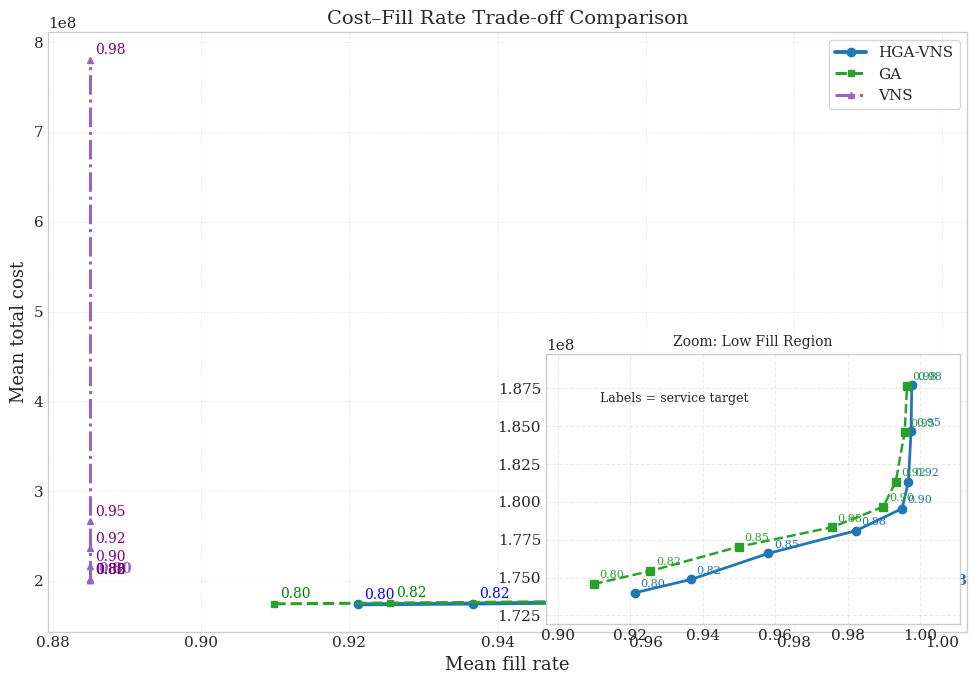

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# =====================================
# LOAD DATA
# =====================================
df_hga = pd.read_csv("output_hga_vns/TRADEOFF_SERVICE_TARGET_RESULTS_HGA-VNS_6.csv")
df_ga  = pd.read_csv("output_ga_ipox_2/TRADEOFF_SERVICE_TARGET_RESULTS_GA_4.csv")
df_vns = pd.read_csv("output_vns/TRADEOFF_SERVICE_TARGET_RESULTS_VNS_4.csv")

# =====================================
# CLEAN + SORT
# =====================================
def clean_df(df):
    return df[df['mean_cost'] < 1e9]

df_hga = clean_df(df_hga).sort_values('mean_fill')
df_ga  = clean_df(df_ga).sort_values('mean_fill')
df_vns = clean_df(df_vns).sort_values('mean_fill')

# =====================================
# STYLE (journal-like)
# =====================================
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

colors = {
    'HGA-VNS': '#1f77b4',   # blue
    'GA': '#2ca02c',        # green
    'VNS': '#9467bd'        # purple
}

fig, ax = plt.subplots(figsize=(10, 7))

# =====================================
# MAIN PLOT
# =====================================
ax.plot(df_hga['mean_fill'], df_hga['mean_cost'],
        marker='o', linewidth=2.8, markersize=6,
        color=colors['HGA-VNS'], label='HGA-VNS')

ax.plot(df_ga['mean_fill'], df_ga['mean_cost'],
        marker='s', linestyle='--', linewidth=2.2, markersize=5,
        color=colors['GA'], label='GA')

ax.plot(df_vns['mean_fill'], df_vns['mean_cost'],
        marker='^', linestyle='-.', linewidth=2.2, markersize=5,
        color=colors['VNS'], label='VNS')

# =====================================
# MINIMAL ANNOTATION (only key points)
# =====================================
def annotate_extremes(ax, df, color):
    # highest fill rate
    best = df.loc[df['mean_fill'].idxmax()]
    ax.annotate(f"{best['svc_target']:.2f}",
                (best['mean_fill'], best['mean_cost']),
                xytext=(6, 5),
                textcoords='offset points',
                fontsize=10,
                color=color,
                weight='bold')

annotate_extremes(ax, df_hga, colors['HGA-VNS'])
annotate_extremes(ax, df_ga, colors['GA'])
annotate_extremes(ax, df_vns, colors['VNS'])

# =====================================
# AXIS SETTINGS
# =====================================
ax.set_xlabel('Mean fill rate')
ax.set_ylabel('Mean total cost')
ax.set_title('Cost–Fill Rate Trade-off Comparison')

# subtle grid
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)


# =====================================
# INSET ZOOM (CRITICAL FOR PUBLICATION)
# =====================================
axins = inset_axes(ax, width="45%", height="45%", loc='lower right') #'lower right'

axins.plot(df_hga['mean_fill'], df_hga['mean_cost'],
           marker='o', linewidth=2, color=colors['HGA-VNS'])

axins.plot(df_ga['mean_fill'], df_ga['mean_cost'],
           marker='s', linestyle='--', linewidth=1.8, color=colors['GA'])


# zoom region (adjust if needed)
#axins.set_xlim(0.985, 1.001)
#axins.set_ylim(1.7e8, 2.0e8)

#axins.set_title("Zoom: HGA-VNS vs GA", fontsize=10)
#axins.grid(True, linestyle='--', alpha=0.4)


# ✅ AUTO-DETECT BEST ZOOM REGION
# Focus on top-performing (high fill rate) region
# =====================================
# Combine HGA + GA only (since zoom compares them)
df_zoom = pd.concat([df_hga, df_ga])

# Select top 30% highest fill rates
#threshold = df_zoom['mean_fill'].quantile(0.7)
threshold = df_zoom['mean_fill'].quantile(0)
df_focus = df_zoom[df_zoom['mean_fill'] >= threshold]

# Compute bounds with padding
x_min = df_focus['mean_fill'].min()
x_max = df_focus['mean_fill'].max()
y_min = df_focus['mean_cost'].min()
y_max = df_focus['mean_cost'].max()

# Add small margins (important for visual clarity)
x_pad = (x_max - x_min) * 0.15
y_pad = (y_max - y_min) * 0.15

axins.set_xlim(x_min - x_pad, x_max + x_pad)
axins.set_ylim(y_min - y_pad, y_max + y_pad)


#axins.set_title("Zoom: High Fill Region", fontsize=10)
axins.set_title("Zoom: Low Fill Region", fontsize=10)
axins.grid(True, linestyle='--', alpha=0.4)



#####
# =====================================
# ✅ ANNOTATE SERVICE TARGET
# =====================================
for df, color in [
    (df_hga, 'blue'),
    (df_ga, 'green'),
    (df_vns, 'purple')
]:
    for _, row in df.iterrows():
        ax.annotate(
            f"{row['svc_target']:.2f}",
            (row['mean_fill'], row['mean_cost']),
            fontsize=10,
            color=color,
            xytext=(4,4),
            textcoords='offset points'
        )


#######


# =====================================
# ✅ ANNOTATE SERVICE TARGET (FOR ZOOM)
# =====================================
for df, color, dy in [
    (df_hga, colors['HGA-VNS'], 6),  # ABOVE
    (df_ga, colors['GA'], -8)        # BELOW
]:
    for _, row in df.iterrows():
        x = row['mean_fill']
        y = row['mean_cost']

        # ✅ Only annotate points inside zoom window
        #if 0.985 <= x <= 1.001 and 1.7e8 <= y <= 2.0e8:        
        if (x_min - x_pad) <= x <= (x_max + x_pad) and \
            (y_min - y_pad) <= y <= (y_max + y_pad):

            axins.annotate(
                f"{row['svc_target']:.2f}",
                (x, y),
                fontsize=8,
                color=color,
                xytext=(4, 4),
                #xytext=(0, dy),
                #ha='center',
                textcoords='offset points'
                #bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )


# ✅ Put text HERE (outside loop)
axins.text(
    x_min + 0.02 * (x_max - x_min),
    y_max - 0.08 * (y_max - y_min),
    "Labels = service target",
    fontsize=9
)

#axins.text(0.986, 1.95e8,
#        "Labels = service target",
#       fontsize=9)


# =====================================
# LEGEND
# =====================================
ax.legend(frameon=True, loc='upper right')

# =====================================
# EXPORT (journal quality)
# =====================================
plt.tight_layout()
plt.savefig("tradeoff_publication.png", dpi=300)
plt.savefig("tradeoff_publication.pdf")  # vector format (best for journals)
plt.show()

